In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score,recall_score,f1_score
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV

In [2]:
df=pd.read_csv(r"D:\Datasets\AL-Based Surviellence\suspicious_behavior_dataset_extended.csv")

In [3]:
df.head()

,person_id,call_count_with_suspects,night_movements_hours,gps_zone_visits,encrypted_app_usage_hours,social_media_threat_score,vpn_usage,device_changes_last_30_days,suspicious_contacts_count,avg_call_duration_min,microphone_activation_events,camera_activation_events,account_login_failures,location_change_frequency,suspicious,last_activity_time,related_person_ids,military_zone_proximity_score
0,1,4,2.367128,3,0.320782,0.255531,1,0,0,4.237585,1,1,0,0.463509,0,2025-05-22 20:06:46.134045,"9565,9169,7636",2.547690
1,2,1,1.512272,2,0.934979,0.361819,1,1,0,2.643535,1,1,3,0.000000,0,2025-06-02 15:12:46.134045,"6616,6323,7198,7384",4.411215
2,3,3,2.030324,5,2.792404,0.757723,0,0,2,4.352084,2,1,0,0.793125,0,2025-05-20 06:16:46.134045,4351,1.157417
3,4,3,2.317275,6,0.920293,0.082273,0,1,1,5.231504,0,3,4,1.411514,0,2025-05-25 23:30:46.134045,"333,1827,3697,892,1371",2.052415
4,5,2,3.241908,6,0.614169,0.825071,0,0,4,2.046954,1,3,3,1.632637,1,2025-05-13 22:47:46.134045,6374,3.647706


In [4]:
df.shape

(10000, 18)

In [5]:
df.isnull().sum()

person_id                        0
call_count_with_suspects         0
night_movements_hours            0
gps_zone_visits                  0
encrypted_app_usage_hours        0
social_media_threat_score        0
vpn_usage                        0
device_changes_last_30_days      0
suspicious_contacts_count        0
avg_call_duration_min            0
microphone_activation_events     0
camera_activation_events         0
account_login_failures           0
location_change_frequency        0
suspicious                       0
last_activity_time               0
related_person_ids               0
military_zone_proximity_score    0
dtype: int64

In [6]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

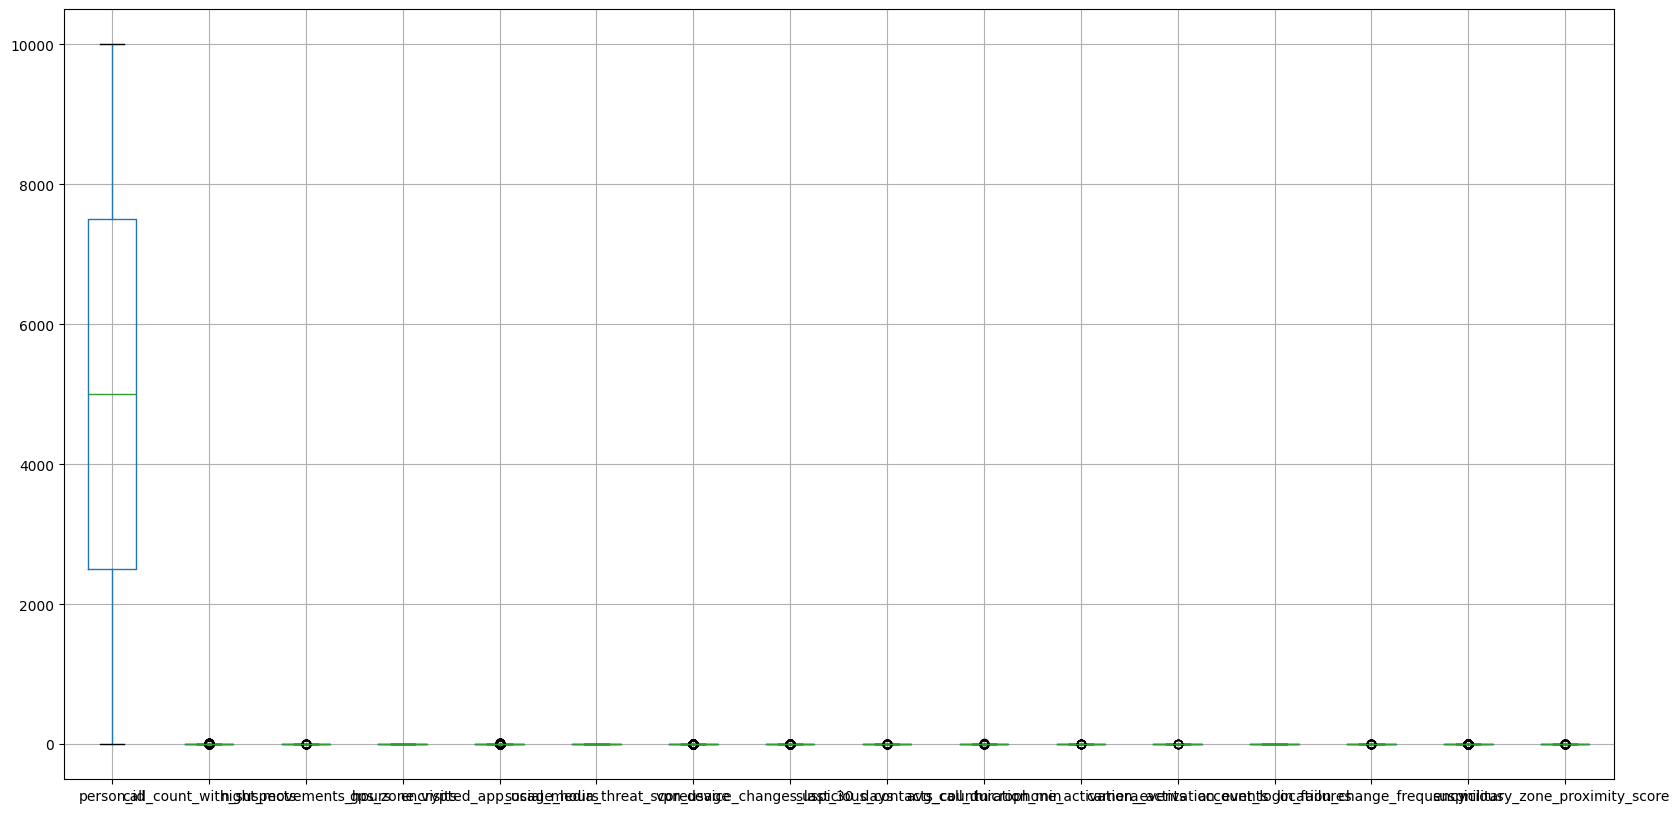

In [7]:
df.boxplot(figsize=(20,10))
plt.show()

In [8]:
df.describe()

,person_id,call_count_with_suspects,night_movements_hours,gps_zone_visits,encrypted_app_usage_hours,social_media_threat_score,vpn_usage,device_changes_last_30_days,suspicious_contacts_count,avg_call_duration_min,microphone_activation_events,camera_activation_events,account_login_failures,location_change_frequency,suspicious,military_zone_proximity_score
count,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,2.99460,1.999987,4.563300,1.496088,0.499795,0.205300,0.494500,1.986600,3.032983,1.012700,0.996700,1.998100,1.007511,0.150000,2.868658
std,2886.89568,1.72246,0.980272,2.875034,1.466813,0.286274,0.403941,0.697437,1.399005,1.469412,1.010861,1.004286,1.414389,0.483119,0.357089,1.585724
min,1.00000,0.00000,0.000000,0.000000,0.000405,0.000130,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.021727
25%,2500.75000,2.00000,1.300554,2.000000,0.436536,0.251810,0.000000,0.000000,1.000000,2.009521,0.000000,0.000000,1.000000,0.672034,0.000000,1.639141
50%,5000.50000,3.00000,1.995025,5.000000,1.054509,0.501803,0.000000,0.000000,2.000000,3.024352,1.000000,1.000000,2.000000,0.993136,0.000000,2.654663
75%,7500.25000,4.00000,2.669350,7.000000,2.098293,0.748906,0.000000,1.000000,3.000000,4.018620,2.000000,2.000000,3.000000,1.331253,0.000000,3.902008
max,10000.00000,11.00000,5.727833,9.000000,10.000000,0.999875,1.000000,5.000000,8.000000,9.303039,7.000000,7.000000,4.000000,2.899351,1.000000,8.904273


In [9]:
df["suspicious"].value_counts()

suspicious
0    8500
1    1500
Name: count, dtype: int64

In [10]:
correlation=df.corr(numeric_only=True)

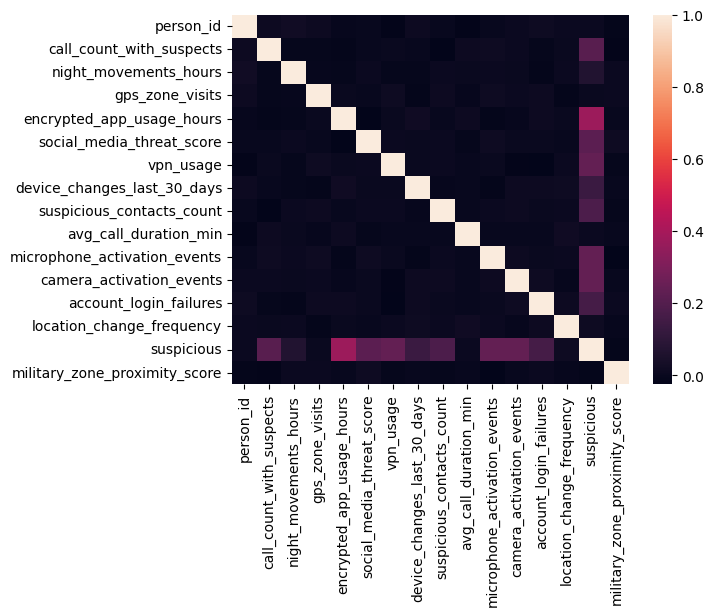

In [11]:
sns.heatmap(data=correlation)
plt.show()

In [12]:
df["last_activity_time"]=pd.to_datetime(df["last_activity_time"])
df["year"]=df["last_activity_time"].dt.year
df["month"]=df["last_activity_time"].dt.month
df["day"]=df["last_activity_time"].dt.day

df["hour"]=df["last_activity_time"].dt.hour
df["minute"]=df["last_activity_time"].dt.minute
df["second"]=df["last_activity_time"].dt.second

In [13]:
df['num_connections'] = df['related_person_ids'].apply(lambda x: len(x.split(',')))

all_ids = df['related_person_ids'].str.split(',').explode()
freq_map = all_ids.value_counts().to_dict()

df['connection_strength'] = df['related_person_ids'].apply(
    lambda x: sum(freq_map[i] for i in x.split(','))
)

In [14]:
X=df.drop(["suspicious","last_activity_time","related_person_ids"],axis=1)
y=df[["suspicious"]]

In [15]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [16]:
rfc=RandomForestClassifier(n_estimators=100,max_depth=5,min_samples_split=2,min_samples_leaf=3)

In [17]:
model=rfc.fit(X_train,y_train)

c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [18]:
importances=model.feature_importances_
print(importances)

[7.94326132e-03 6.04955257e-02 1.38308145e-02 2.52402550e-03
 3.05152122e-01 1.26001110e-01 1.15119513e-01 1.66697289e-02
 4.05181964e-02 6.92692648e-03 1.07143955e-01 1.16898363e-01
 4.57469735e-02 6.50271761e-03 5.63004855e-03 0.00000000e+00
 2.86899446e-04 5.93519754e-03 4.36962276e-03 6.40841545e-03
 0.00000000e+00 1.69495559e-03 4.20162693e-03]


In [19]:
import pandas as pd

feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='importance', ascending=False)

print(feature_importance)

                          feature  importance
4       encrypted_app_usage_hours    0.305152
5       social_media_threat_score    0.126001
11       camera_activation_events    0.116898
6                       vpn_usage    0.115120
10   microphone_activation_events    0.107144
1        call_count_with_suspects    0.060496
12         account_login_failures    0.045747
8       suspicious_contacts_count    0.040518
7     device_changes_last_30_days    0.016670
2           night_movements_hours    0.013831
0                       person_id    0.007943
9           avg_call_duration_min    0.006927
13      location_change_frequency    0.006503
19                         minute    0.006408
17                            day    0.005935
14  military_zone_proximity_score    0.005630
18                           hour    0.004370
22            connection_strength    0.004202
3                 gps_zone_visits    0.002524
21                num_connections    0.001695
16                          month 

In [20]:
important_features = feature_importance[feature_importance['importance'] > 0.01]['feature']

X_train_selected = X_train[important_features]
X_test_selected = X_test[important_features]

In [21]:
model.fit(X_train_selected, y_train)
y_pred = model.predict(X_test_selected)

c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [22]:
param_dist={'n_estimators':[100,300,500],'max_depth':[2,4,6,10],'min_samples_split':[2,3],'min_samples_leaf':[2,4,6],'max_features':[2,5,7,10]}
rc=RandomizedSearchCV(model,param_distributions=param_dist,verbose=2,n_iter=50,n_jobs=-1,cv=3)

In [23]:
model=rc.fit(X_train_selected,y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


c:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [24]:
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(precision_score(y_test,y_pred))
print(recall_score(y_test,y_pred))
print(f1_score(y_test,y_pred))

0.8875
[[1698    2]
 [ 223   77]]
0.9746835443037974
0.25666666666666665
0.40633245382585753


In [25]:
print(model.best_params_)

{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 7, 'max_depth': 10}


In [26]:
y_pred=model.predict(X_test_selected)

In [27]:
#import joblib
#joblib.dump(model, "surveillance_model.pkl")

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 26 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   person_id                      10000 non-null  int64         
 1   call_count_with_suspects       10000 non-null  int64         
 2   night_movements_hours          10000 non-null  float64       
 3   gps_zone_visits                10000 non-null  int64         
 4   encrypted_app_usage_hours      10000 non-null  float64       
 5   social_media_threat_score      10000 non-null  float64       
 6   vpn_usage                      10000 non-null  int64         
 7   device_changes_last_30_days    10000 non-null  int64         
 8   suspicious_contacts_count      10000 non-null  int64         
 9   avg_call_duration_min          10000 non-null  float64       
 10  microphone_activation_events   10000 non-null  int64         
 11  camera_activation_events   

In [29]:
df.columns

Index(['person_id', 'call_count_with_suspects', 'night_movements_hours',
       'gps_zone_visits', 'encrypted_app_usage_hours',
       'social_media_threat_score', 'vpn_usage', 'device_changes_last_30_days',
       'suspicious_contacts_count', 'avg_call_duration_min',
       'microphone_activation_events', 'camera_activation_events',
       'account_login_failures', 'location_change_frequency', 'suspicious',
       'last_activity_time', 'related_person_ids',
       'military_zone_proximity_score', 'year', 'month', 'day', 'hour',
       'minute', 'second', 'num_connections', 'connection_strength'],
      dtype='str')

In [30]:
print(X)

      person_id  call_count_with_suspects  night_movements_hours  \
0             1                         4               2.367128   
1             2                         1               1.512272   
2             3                         3               2.030324   
3             4                         3               2.317275   
4             5                         2               3.241908   
...         ...                       ...                    ...   
9995       9996                         3               1.099812   
9996       9997                         3               1.254584   
9997       9998                         3               1.298719   
9998       9999                         3               1.847938   
9999      10000                         3               1.376730   

      gps_zone_visits  encrypted_app_usage_hours  social_media_threat_score  \
0                   3                   0.320782                   0.255531   
1                   2    

In [38]:
X.columns

Index(['person_id', 'call_count_with_suspects', 'night_movements_hours',
       'gps_zone_visits', 'encrypted_app_usage_hours',
       'social_media_threat_score', 'vpn_usage', 'device_changes_last_30_days',
       'suspicious_contacts_count', 'avg_call_duration_min',
       'microphone_activation_events', 'camera_activation_events',
       'account_login_failures', 'location_change_frequency',
       'military_zone_proximity_score', 'year', 'month', 'day', 'hour',
       'minute', 'second', 'num_connections', 'connection_strength'],
      dtype='str')

In [40]:
X.head()

,person_id,call_count_with_suspects,night_movements_hours,gps_zone_visits,encrypted_app_usage_hours,social_media_threat_score,vpn_usage,device_changes_last_30_days,suspicious_contacts_count,avg_call_duration_min,...,location_change_frequency,military_zone_proximity_score,year,month,day,hour,minute,second,num_connections,connection_strength
0,1,4,2.367128,3,0.320782,0.255531,1,0,0,4.237585,...,0.463509,2.547690,2025,5,22,20,6,46,3,10
1,2,1,1.512272,2,0.934979,0.361819,1,1,0,2.643535,...,0.000000,4.411215,2025,6,2,15,12,46,4,14
2,3,3,2.030324,5,2.792404,0.757723,0,0,2,4.352084,...,0.793125,1.157417,2025,5,20,6,16,46,1,5
3,4,3,2.317275,6,0.920293,0.082273,0,1,1,5.231504,...,1.411514,2.052415,2025,5,25,23,30,46,5,17
4,5,2,3.241908,6,0.614169,0.825071,0,0,4,2.046954,...,1.632637,3.647706,2025,5,13,22,47,46,1,4
